# 03 – GradCAM Analysis for the Event Classifier
**Project:** AI Football Event Classifier (CNN) — Yannick Maas

Loads `outputs/baseline_cnn_event.pth` (trained in `02_baseline_model.ipynb`)
and visualises GradCAM heatmaps for sample test images from each event folder
(goal, freekick, yellowcard, …).


In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [2]:
OUTPUT_DIR     = Path('outputs')
EVENT_MANIFEST = OUTPUT_DIR / 'manifest_events.csv'
EVENT_CKPT     = OUTPUT_DIR / 'baseline_cnn_event.pth'
IMG_SIZE       = (128, 128)

df       = pd.read_csv(EVENT_MANIFEST)
test_df  = df[df['split'] == 'test'].reset_index(drop=True)
print(f'Event manifest: {len(df):,} rows  |  test: {len(test_df):,}')
print('Event folders:', sorted(df['label'].unique()))

Event manifest: 1,500 rows  |  test: 225
Event folders: ['corner', 'freekick', 'gattempts', 'goal', 'offside', 'playercelebration', 'plentystock', 'redc', 'spectator', 'yellowcard']


In [3]:
# ── Rebuild the same SimpleCNN used during training & load checkpoint ───────
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.backbone = nn.Sequential(
            nn.Conv2d(3,  32, 3, padding=1), nn.BatchNorm2d(32),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64),  nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64,128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128,256,3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(4),
        )
        self.flatten = nn.Flatten()
        self.dropout = nn.Dropout(0.4)
        self.head    = nn.Linear(256 * 4 * 4, num_classes)
    def forward(self, x):
        return self.head(self.dropout(self.flatten(self.backbone(x))))

ckpt          = torch.load(EVENT_CKPT, map_location=DEVICE)
event_classes = ckpt['classes']
idx2event     = {i: c for i, c in enumerate(event_classes)}
print(f'Loaded {len(event_classes)} event classes: {event_classes}')

model = SimpleCNN(len(event_classes)).to(DEVICE)
model.load_state_dict(ckpt['state_dict'])
model.eval()
print('Event CNN ready')

Loaded 10 event classes: ['corner', 'freekick', 'gattempts', 'goal', 'offside', 'playercelebration', 'plentystock', 'redc', 'spectator', 'yellowcard']
Event CNN ready


In [4]:
# ── GradCAM implementation ──────────────────────────────────────────────────
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self._fwd = self._bwd = None
        self.gradients = self.activations = None
    def _fhook(self, m, i, o):     self.activations = o.detach()
    def _bhook(self, m, gi, go):   self.gradients   = go[0].detach()
    def _register(self):
        self._remove()
        self._fwd = self.target_layer.register_forward_hook(self._fhook)
        self._bwd = self.target_layer.register_full_backward_hook(self._bhook)
    def _remove(self):
        for h_attr in ('_fwd', '_bwd'):
            h = getattr(self, h_attr)
            if h is not None:
                try: h.remove()
                except Exception: pass
                setattr(self, h_attr, None)
    def __call__(self, x, class_idx=None):
        self.gradients = self.activations = None
        self._register()
        self.model.zero_grad()
        logits = self.model(x)
        if class_idx is None:
            class_idx = int(logits.argmax(1).item())
        logits[0, class_idx].backward()
        grads, acts = self.gradients, self.activations
        self._remove()
        if grads is None or acts is None:
            raise RuntimeError('GradCAM failed to capture gradients/activations')
        weights = grads.mean(dim=(2, 3), keepdim=True)
        cam_map = F.relu((weights * acts).sum(dim=1, keepdim=True)).squeeze().cpu().numpy()
        if cam_map.max() > 0:
            cam_map = (cam_map - cam_map.min()) / (cam_map.max() - cam_map.min())
        return cam_map, class_idx


def overlay_heatmap(img_pil, cam_map, alpha=0.45):
    img_np  = np.array(img_pil.resize(IMG_SIZE))
    heatmap = cv2.resize(cam_map.astype(np.float32), IMG_SIZE, interpolation=cv2.INTER_LINEAR)
    heatmap = np.clip(heatmap, 0, 1)
    colored = (cm.jet(heatmap)[:, :, :3] * 255).astype(np.uint8)
    return (alpha * colored + (1 - alpha) * img_np).astype(np.uint8)

# Pick the last conv layer for GradCAM
last_conv = [l for l in model.backbone if isinstance(l, nn.Conv2d)][-1]
cam_gen   = GradCAM(model, last_conv)
print('GradCAM target layer:', last_conv)

GradCAM target layer: Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))


Visualising 10 samples (one per event folder)


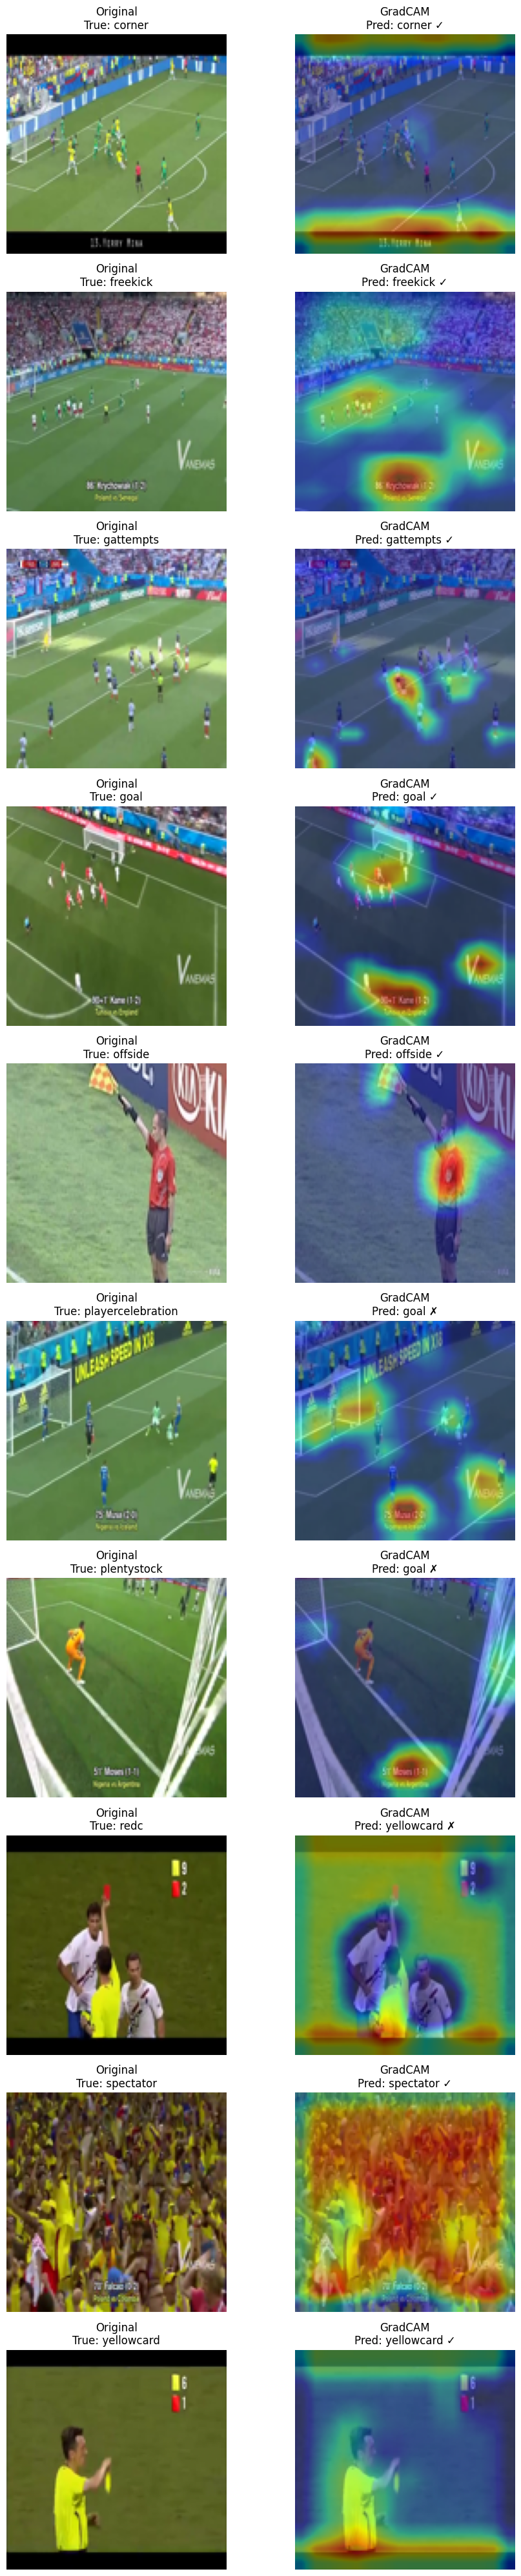

Saved → outputs/baseline_gradcam_event.png


In [5]:
# ── One sample per event folder, with GradCAM overlay ───────────────────────
preprocess = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def prepare(path):
    img = Image.open(path).convert('RGB')
    tensor = preprocess(img).unsqueeze(0).to(DEVICE)
    tensor.requires_grad_(True)
    return img, tensor

samples = []
for folder in event_classes:
    subset = test_df[test_df['label'] == folder]
    if len(subset) == 0: continue
    samples.append(subset.sample(1, random_state=1).iloc[0])

print(f'Visualising {len(samples)} samples (one per event folder)')

fig, axes = plt.subplots(len(samples), 2, figsize=(10, 4 * len(samples)))
if len(samples) == 1:
    axes = axes[np.newaxis, :]

for r, row in enumerate(samples):
    img_pil, tensor = prepare(row['path'])
    cam_map, pred_idx = cam_gen(tensor)
    pred_label = idx2event[pred_idx]
    true_label = row['label']
    correct = '✓' if pred_label == true_label else '✗'

    axes[r, 0].imshow(img_pil.resize(IMG_SIZE)); axes[r, 0].axis('off')
    axes[r, 0].set_title(f'Original\nTrue: {true_label}')
    axes[r, 1].imshow(overlay_heatmap(img_pil, cam_map)); axes[r, 1].axis('off')
    axes[r, 1].set_title(f'GradCAM\nPred: {pred_label} {correct}')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'baseline_gradcam_event.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved → outputs/baseline_gradcam_event.png')

In [7]:
# ── Predict a single arbitrary image (handy demo helper) ────────────────────
def predict_event(image_path: str, show: bool = True):
    img_pil, tensor = prepare(image_path)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0].cpu().numpy()
    top = probs.argsort()[::-1][:3]
    print(f'Top-3 predictions for {Path(image_path).name}:')
    for i in top:
        print(f'  {idx2event[i]:<22s}  {probs[i]*100:5.1f}%')
    if show:
        cam_map, pred_idx = cam_gen(tensor)
        fig, ax = plt.subplots(1, 2, figsize=(10, 5))
        ax[0].imshow(img_pil.resize(IMG_SIZE)); ax[0].axis('off'); ax[0].set_title('Input')
        ax[1].imshow(overlay_heatmap(img_pil, cam_map)); ax[1].axis('off')
        ax[1].set_title(f'GradCAM – {idx2event[pred_idx]}')
        plt.tight_layout(); plt.show()
    return idx2event[top[0]], float(probs[top[0]])

# Example: predict_event(test_df.iloc[0]['path'])

In [8]:
import ipywidgets as widgets
from IPython.display import display

# 1. Create the file upload widget, a trigger button, and an output container
uploader = widgets.FileUpload(accept='image/*', multiple=False)
predict_btn = widgets.Button(description="Predict & Run GradCAM", button_style='success')
output_area = widgets.Output()

# 2. Define the button callback function
def on_predict_clicked(b):
    with output_area:
        output_area.clear_output() # Clear previous results
        
        if not uploader.value:
            print("❌ Please upload an image first!")
            return
        
        # Handle structural differences between ipywidgets v7 and v8
        try:
            # ipywidgets v8+ structure (tuple of dicts)
            file_info = uploader.value[0]
            filename = file_info['name']
            content = file_info['content']
        except (KeyError, TypeError, IndexError):
            # ipywidgets v7 structure (dictionary)
            filename = list(uploader.value.keys())[0]
            content = uploader.value[filename]['content']
            
        # Save the uploaded file bytes locally to interface with your predict_event function
        upload_path = f"uploaded_{filename}"
        with open(upload_path, "wb") as f:
            f.write(content)
            
        print(f"Processing image: {filename}...\n")
        
        # 3. Call your notebook's existing prediction utility
        predict_event(upload_path, show=True)

# Connect the button click to the handler
predict_btn.on_click(on_predict_clicked)

# Display the user interface elements vertically
display(widgets.VBox([uploader, predict_btn, output_area]))

## Outputs

- `outputs/baseline_gradcam_event.png` — one GradCAM panel per event class  
- `predict_event(path)` — utility to predict an arbitrary image and show its heatmap
